In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')

In [9]:
# Load the dataset

df = pd.read_csv(r"C:\Users\onc\Downloads\Life Expectancy Data 1.csv")
df.head(5)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [10]:
df.shape

(2938, 22)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [12]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [13]:
# Data cleaning

df.columns = df.columns.str.strip()

In [14]:
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [ ]:
# Drop Rows with Missing Target

In [15]:
target = "Life expectancy"
print("Missing target rows:", df[target].isnull().sum())

df = df.dropna(subset=[target]).reset_index(drop=True)
print("Shape after dropping:", df.shape)

Missing target rows: 10
Shape after dropping: (2928, 22)


In [16]:
# Check Duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
# Encode Status (Developing=0, Developed=1)

print("Status values:", df['Status'].unique())
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})
df['Status'].value_counts()

Status values: ['Developing' 'Developed']


Status
0    2416
1     512
Name: count, dtype: int64

In [19]:
# Visualize Missing Values (Before Imputation)

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
print("Columns with missing values (%):")
print(miss_pct.round(2))

Columns with missing values (%):
Population                         21.99
Hepatitis B                        18.89
GDP                                15.13
Total expenditure                   7.72
Alcohol                             6.59
Schooling                           5.46
Income composition of resources     5.46
thinness 5-9 years                  1.09
thinness  1-19 years                1.09
BMI                                 1.09
Diphtheria                          0.65
Polio                               0.65
dtype: float64


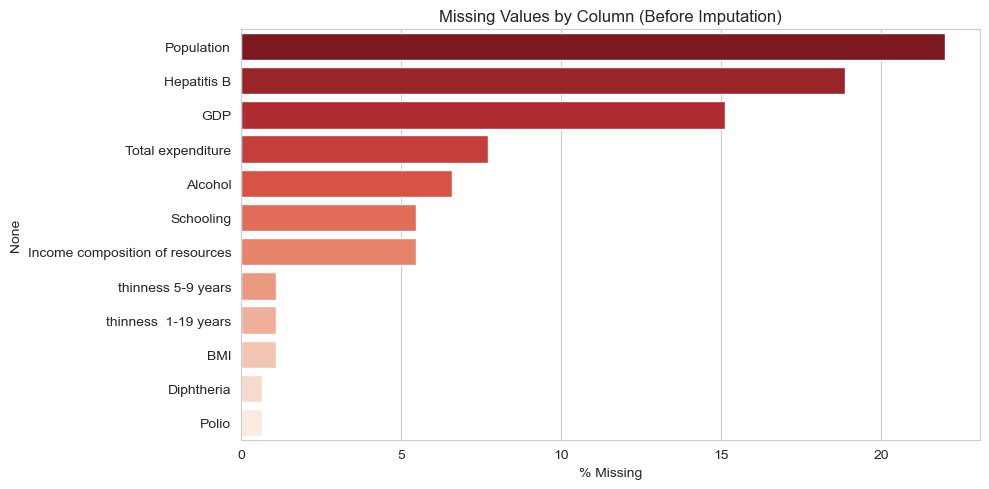

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=miss_pct.values,
    y=miss_pct.index,
    hue=miss_pct.index,
    palette="Reds_r",
    legend=False
)

plt.xlabel("% Missing")
plt.title("Missing Values by Column (Before Imputation)")
plt.tight_layout()
plt.show()

In [21]:
#  Impute missing values.

numeric_cols = df.select_dtypes(include=[np.number]).columns

# Step 1: Fill with country median
for col in numeric_cols:
    country_median = df.groupby("Country")[col].transform("median")
    df[col] = df[col].fillna(country_median)

# Step 2: Fill any remaining missing values with overall median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values AFTER imputation:")
print(df.isnull().sum().sum())

Missing values AFTER imputation:
0


In [ ]:
# Exploratory Data Analysis


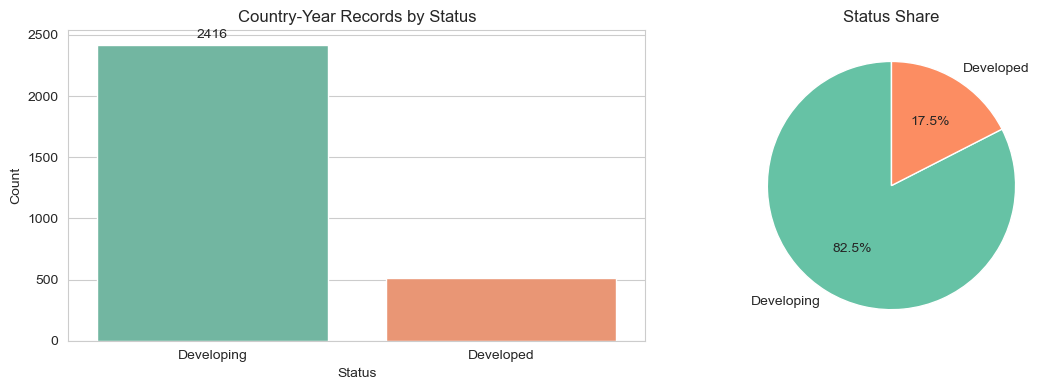

In [22]:
# Status Distribution (Developed vs Developing)

status_counts = df["Status"].value_counts().rename({0: "Developing", 1: "Developed"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

# Bar
sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette="Set2",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Country-Year Records by Status")
axes[0].set_ylabel("Count")
axes[0].bar_label(axes[0].containers[0], padding=3)

# Pie
axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    startangle=90
)
axes[1].set_title("Status Share")

plt.tight_layout()
plt.show()

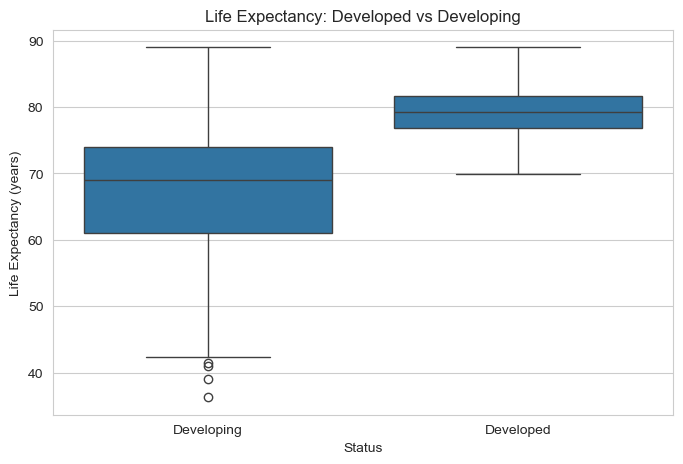

,Life expectancy
Status,
Developing,69.00
Developed,79.25


In [23]:
# Life Expectancy by Status

plt.figure(figsize=(8, 5))
sns.boxplot(
    x=df['Status'].map({0: 'Developing', 1: 'Developed'}),
    y=df[target]
)
plt.title('Life Expectancy: Developed vs Developing')
plt.xlabel('Status')
plt.ylabel('Life Expectancy (years)')
plt.show()

pd.DataFrame(df.groupby("Status")[target].median().round(2)).rename(
    index={0: "Developing", 1: "Developed"}
) 

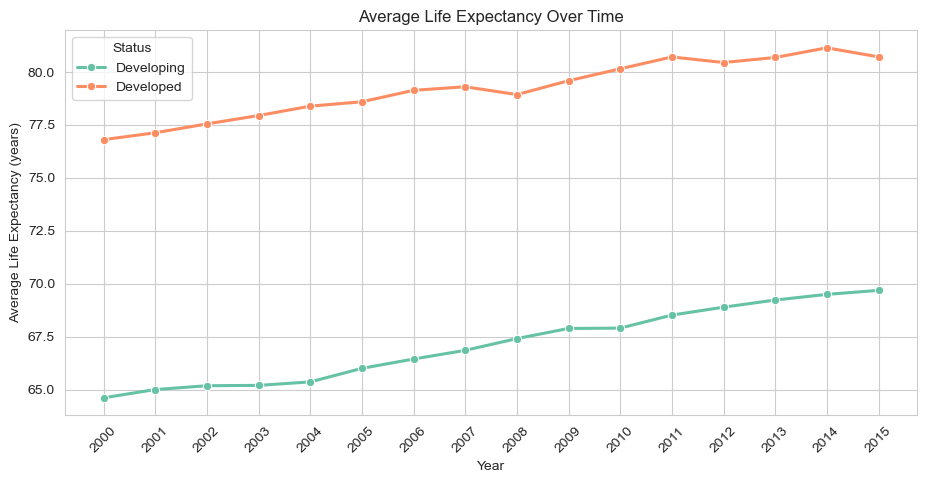

In [24]:
# Life Expectancy Trend Over Years

yearly = df.groupby(['Year', 'Status'])[target].mean().reset_index()
yearly['Status'] = yearly['Status'].map({0: 'Developing', 1: 'Developed'})

plt.figure(figsize=(11, 5))
sns.lineplot(data=yearly, x='Year', y=target, hue='Status',
             marker='o', palette='Set2', linewidth=2.2)
plt.title('Average Life Expectancy Over Time')
plt.ylabel('Average Life Expectancy (years)')
plt.xticks(yearly['Year'].unique(), rotation=45)
plt.show()

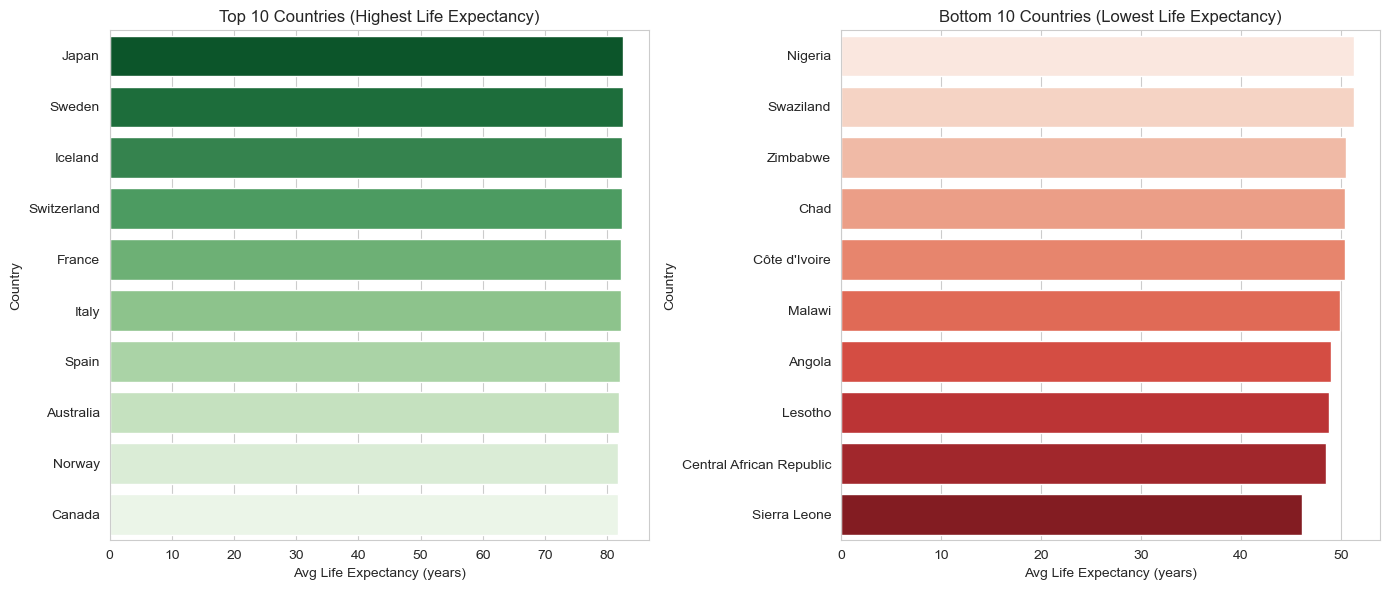

In [25]:
# Top 10 & Bottom 10 Countries by Average Life Expectancy

country_avg = df.groupby("Country")[target].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

# Top 10
top10 = country_avg.tail(10)
top10 = top10.sort_values(ascending=False)
sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="Greens_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 10 Countries (Highest Life Expectancy)")
axes[0].set_xlabel("Avg Life Expectancy (years)")


# Bottom 10
bot10 = country_avg.head(10)
bot10 = bot10.sort_values(ascending=False)
sns.barplot(
    x=bot10.values,
    y=bot10.index,
    hue=bot10.index,
    palette="Reds",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Bottom 10 Countries (Lowest Life Expectancy)")
axes[1].set_xlabel("Avg Life Expectancy (years)")

plt.tight_layout()
plt.show()

In [26]:
# Drop Country Column

df = df.drop(columns=['Country'])
print("Shape after dropping Country:", df.shape)

Shape after dropping Country: (2928, 21)


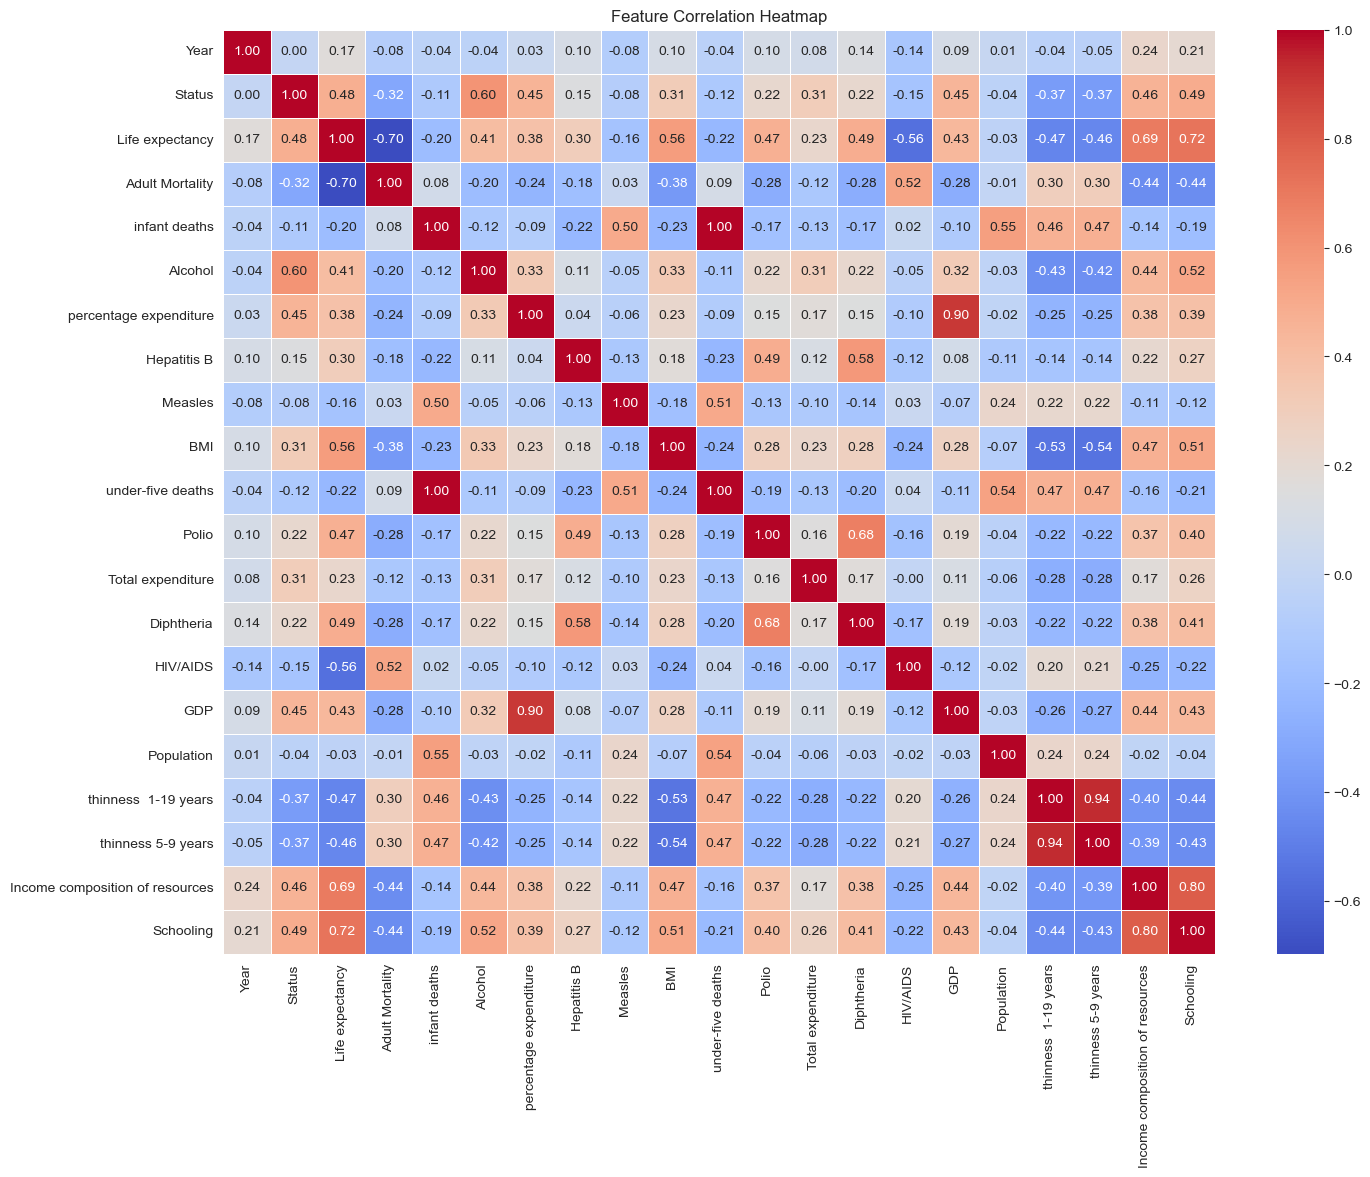

In [27]:
# Correlation Heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

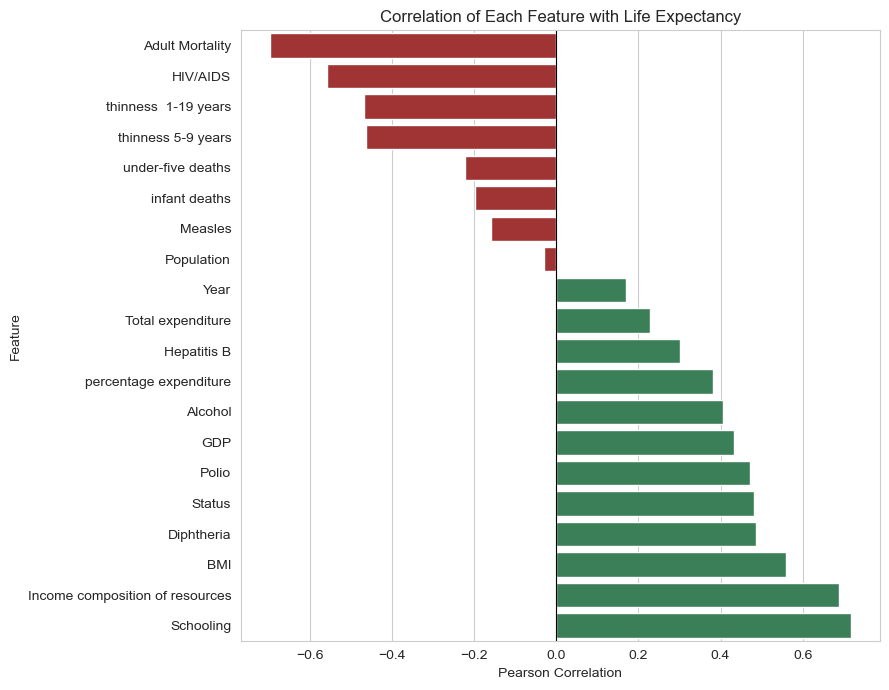

In [28]:
# Feature Correlation with Target

target_corr = (
    df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values()
    .reset_index()
)

target_corr.columns = ["Feature", "Correlation"]

colors = [
    "firebrick" if c < 0 else "seagreen"
    for c in target_corr["Correlation"]
]

plt.figure(figsize=(9, 7))

sns.barplot(
    data=target_corr,
    x="Correlation",
    y="Feature",
    hue="Feature",
    palette=colors,
    legend=False
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with Life Expectancy")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [29]:
# Droping Less Importance Feature

df = df.drop(columns=["Year", "Population"])

In [30]:
X_tmp = df.drop(columns=[target])
corr_matrix = X_tmp.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            col1 = corr_matrix.columns[j]
            col2 = corr_matrix.columns[i]
            corr = corr_matrix.iloc[i, j]
            print(f"{col1} <-> {col2} = {corr:.3f}")
            columns_to_drop.append(col2)

columns_to_drop = list(set(columns_to_drop))
print("\nColumns to drop:", columns_to_drop)

infant deaths <-> under-five deaths = 0.997
percentage expenditure <-> GDP = 0.902
thinness  1-19 years <-> thinness 5-9 years = 0.939

Columns to drop: ['under-five deaths', 'GDP', 'thinness 5-9 years']


In [31]:
df = df.drop(columns=columns_to_drop)
print("Shape after dropping correlated features:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping correlated features: (2928, 16)
Remaining columns: ['Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'Income composition of resources', 'Schooling']


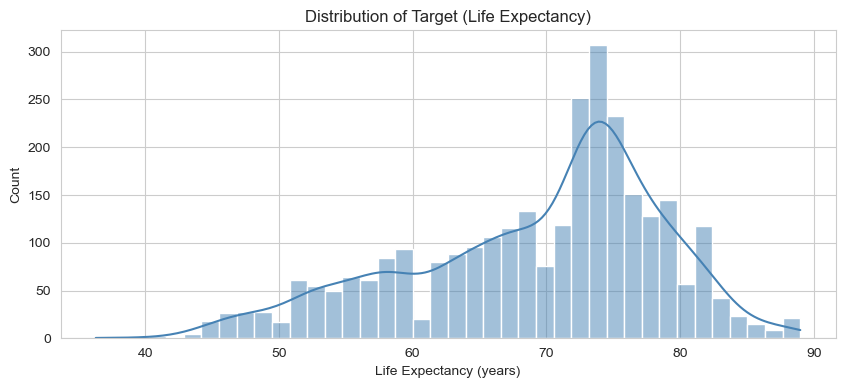

In [32]:
# Target Distribution

plt.figure(figsize=(10, 4))
sns.histplot(df[target], kde=True, bins=40, color='steelblue')
plt.title('Distribution of Target (Life Expectancy)')
plt.xlabel('Life Expectancy (years)')
plt.show()

In [33]:
# Top Features vs Target (Scatter)

target_corr_abs = df.corr()[target].drop(target).abs().sort_values(ascending=False)
top_features = target_corr_abs.head(6).index.tolist()
print("Top 6 features by |corr| with target:")
print(target_corr_abs.head(6))

Top 6 features by |corr| with target:
Schooling                          0.717314
Adult Mortality                    0.696359
Income composition of resources    0.688591
BMI                                0.558888
HIV/AIDS                           0.556556
Diphtheria                         0.485097
Name: Life expectancy, dtype: float64


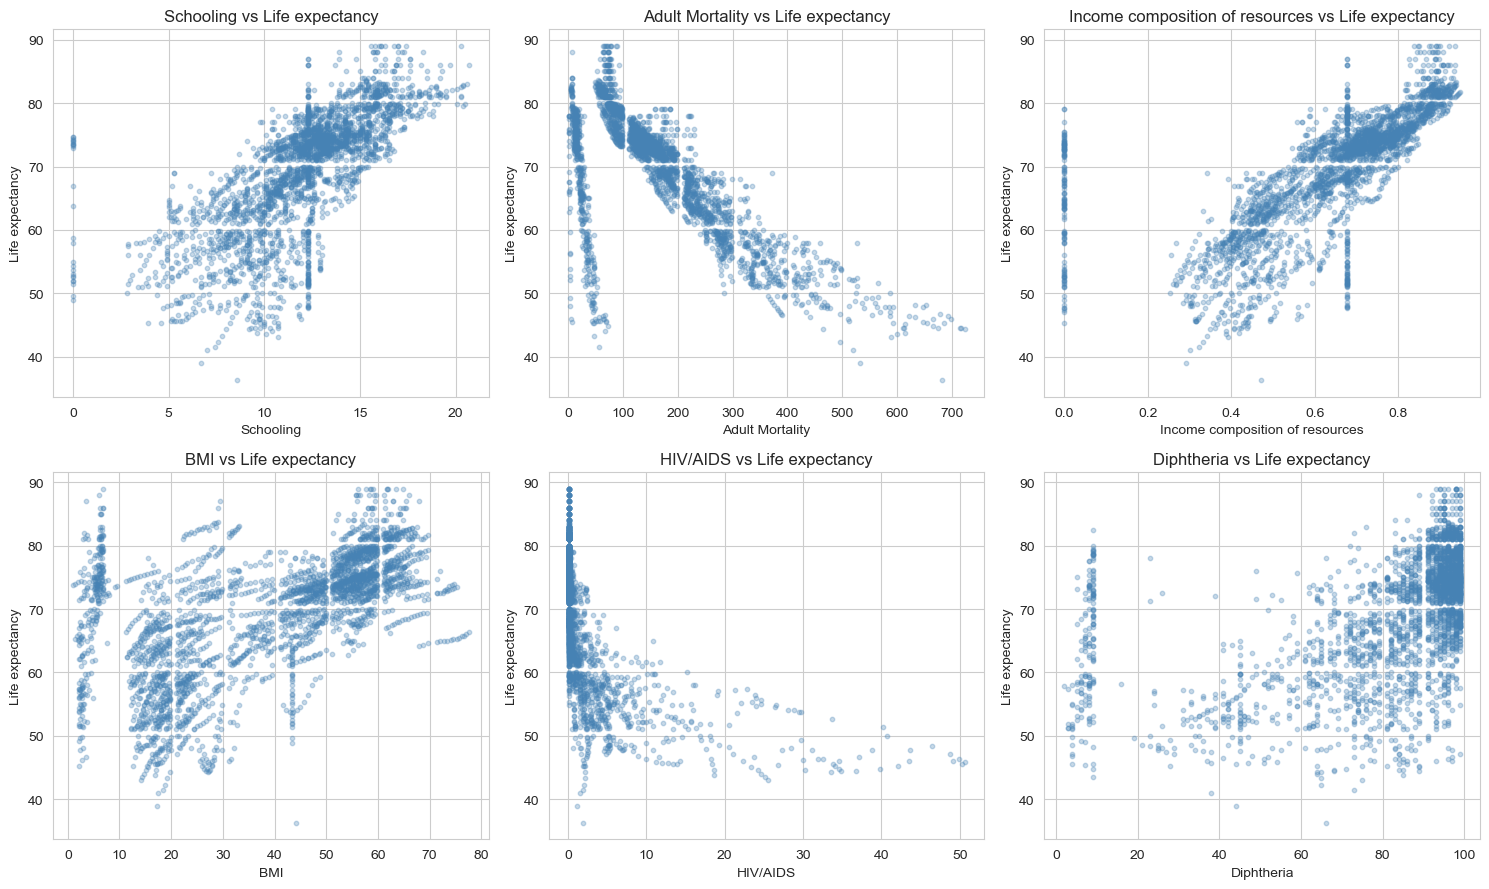

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    ax.scatter(df[col], df[target], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f'{col} vs {target}')

plt.tight_layout()
plt.show()

In [35]:
# Train / Test Split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (2342, 15)  X_test: (586, 15)
y_train: (2342,)  y_test: (586,)


In [36]:
# Feature Scaling

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("n_features:", n_features)

n_features: 15


In [37]:
 # Build the Artificial Neural Network (ANN)
model = Sequential()

# ---------------------- Input Layer ----------------------

# Define the input shape (number of input features)
model.add(Input(shape=(n_features,)))

# ---------------------- Hidden Layer 1 ----------------------

# Add first hidden layer with 128 neurons and ReLU activation
model.add(Dense(128, activation='relu'))

# Normalize the outputs of the previous layer
# This helps stabilize and speed up training
model.add(BatchNormalization())

# Randomly deactivate 20% of neurons during training
# Helps reduce overfitting
model.add(Dropout(0.2))

# ---------------------- Hidden Layer 2 ----------------------

# Add second hidden layer with 64 neurons
model.add(Dense(64, activation='relu'))

# Normalize activations
model.add(BatchNormalization())

# Drop 20% of neurons during training
model.add(Dropout(0.2))

# ---------------------- Hidden Layer 3 ----------------------

# Add third hidden layer with 32 neurons
model.add(Dense(32, activation='relu'))

# Normalize activations
model.add(BatchNormalization())

# Drop 10% of neurons during training
model.add(Dropout(0.1))

# ---------------------- Output Layer ----------------------

# Add output layer with 1 neuron
# Linear activation is used for regression problems
model.add(Dense(1, activation='linear'))

# ---------------------- Compile the Model ----------------------

# Configure the model for training
model.compile(

    # Adam optimizer updates weights during training
    optimizer=Adam(learning_rate=0.001),

    # Mean Squared Error is the loss function for regression
    loss='mse',

    # Mean Absolute Error is used to evaluate model performance
    metrics=['mae']
)

# Display the model architecture, output shapes, and total parameters
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [38]:
# # Train the Model

# early_stop = EarlyStopping(
#     monitor="val_loss",
#     min_delta=0.01,
#     patience=25,
#     verbose=1,
#     mode="min",
#     restore_best_weights=True
# )

# history = model.fit(
#     X_train_scaled, y_train,
#     validation_split=0.2,
#     epochs=200,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=1
# )





# Train the Model

# Create an EarlyStopping callback
early_stop = EarlyStopping(

    # Monitor the validation loss after every epoch
    monitor="val_loss",

    # Consider it an improvement only if validation loss decreases
    # by at least 0.01
    min_delta=0.01,

    # Wait for 25 epochs without improvement before stopping
    patience=25,

    # Display a message when training stops early
    verbose=1,

    # Since lower validation loss is better, use "min"
    mode="min",

    # Restore the model weights from the epoch with the lowest validation loss
    restore_best_weights=True
)

# Train the ANN model
history = model.fit(

    # Input features for training
    X_train_scaled,

    # Target values
    y_train,

    # Use 20% of the training data as validation data
    validation_split=0.2,

    # Maximum number of times the model will see the entire dataset
    epochs=200,

    # Number of samples processed before updating weights
    batch_size=32,

    # Apply EarlyStopping while training
    callbacks=[early_stop],

    # Show training progress after every epoch
    verbose=1
)






Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4839.0796 - mae: 69.0970 - val_loss: 4697.0107 - val_mae: 67.8668
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4727.0083 - mae: 68.4822 - val_loss: 4505.9907 - val_mae: 66.5342
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4576.7598 - mae: 67.4628 - val_loss: 4351.3950 - val_mae: 65.4886
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4379.3130 - mae: 65.9965 - val_loss: 4156.6768 - val_mae: 64.0866
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4123.6582 - mae: 64.0337 - val_loss: 4022.9685 - val_mae: 63.1289
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3803.0005 - mae: 61.4807 - val_loss: 3749.8748 - val_mae: 60.9858
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3448.0571 - mae: 58.5259 - val_loss: 3321.5137 - val_mae: 57.4209
Epoch 8/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3054.3132 - mae: 55.0169 - val_loss: 2947.8181 - val_mae: 54.1042


In [39]:
# Evaluate on Test Set

y_pred = model.predict(X_test_scaled).flatten()

y_test_arr = y_test.values
for actual, pred in zip(y_test_arr[10:20], y_pred[10:20]):
    print(f"Actual: {actual:>6.2f}   Predicted: {pred:>6.2f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Actual:  78.50   Predicted:  80.98
Actual:  75.30   Predicted:  75.38
Actual:  74.90   Predicted:  75.09
Actual:  79.30   Predicted:  79.58
Actual:  68.30   Predicted:  68.34
Actual:  75.00   Predicted:  70.50
Actual:  77.00   Predicted:  71.50
Actual:  53.40   Predicted:  54.30
Actual:  67.00   Predicted:  56.48
Actual:  52.50   Predicted:  54.00


In [40]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R\u00b2 Score : {r2:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")

R² Score : 0.9338
MAE       : 1.6608
RMSE      : 2.4206


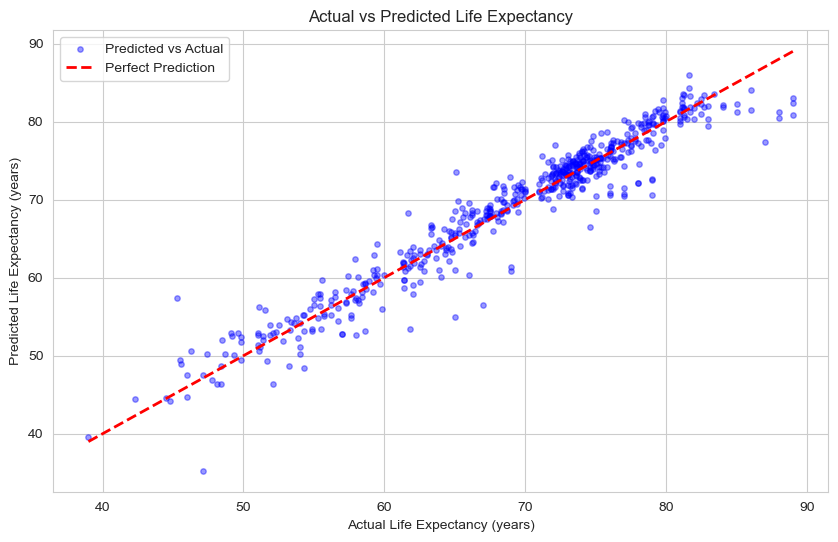

In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.4, s=15, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Life Expectancy (years)')
plt.ylabel('Predicted Life Expectancy (years)')
plt.title('Actual vs Predicted Life Expectancy')
plt.legend()
plt.show()

In [ ]:
# Inference on New Data

# Helper that takes a raw record (matching the **final feature set** after correlation pruning), applies the same scaling pipeline, then predicts using the trained ANN.

In [42]:
df.head()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,Income composition of resources,Schooling
0,0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,6.0,8.16,65.0,0.1,17.2,0.479,10.1
1,0,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,58.0,8.18,62.0,0.1,17.5,0.476,10.0
2,0,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,62.0,8.13,64.0,0.1,17.7,0.470,9.9
3,0,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,67.0,8.52,67.0,0.1,17.9,0.463,9.8
4,0,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,68.0,7.87,68.0,0.1,18.2,0.454,9.5


In [43]:
import pandas as pd

# Feature columns used during training
feature_cols = X.columns.tolist()

# Take the second sample from the test set
sample = X_test.iloc[1]

# Prepare input
input_df = pd.DataFrame([sample])[feature_cols]
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled, verbose=0)
final_prediction = prediction.flatten()[0]

# Display results
print(f"Predicted Life Expectancy: {final_prediction:.2f} years")
print(f"Actual Life Expectancy: {y_test.iloc[1]:.2f} years")

Predicted Life Expectancy: 71.42 years
Actual Life Expectancy: 71.80 years


In [44]:
# Save the model and scaler

import joblib

# Save the model
model.save("life_expectancy_model.keras")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature order
joblib.dump(X.columns.tolist(), "feature_cols.pkl")

['feature_cols.pkl']

In [46]:
# Load and predict


import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# Load model, scaler, and feature order
model = load_model("life_expectancy_model.keras")
scaler = joblib.load("scaler.pkl")
feature_cols = joblib.load("feature_cols.pkl")

# Your input values
sample = {
    "Status": 0.000,
    "Adult Mortality": 129.000,
    "infant deaths": 92.000,
    "Alcohol": 0.010,
    "percentage expenditure": 0.000,
    "Hepatitis B": 97.000,
    "Measles": 240.000,
    "BMI": 18.300,
    "Polio": 97.000,
    "Total expenditure": 2.800,
    "Diphtheria": 97.000,
    "HIV/AIDS": 0.100,
    "thinness  1-19 years": 17.900,
    "Income composition of resources": 0.575,
    "Schooling": 10.200
}

# Convert to DataFrame in correct feature order
input_df = pd.DataFrame([sample])[feature_cols]

# Scale
input_scaled = scaler.transform(input_df)

# Predict
prediction = model.predict(input_scaled, verbose=0).flatten()[0]

actual = 71.80  
print(f"Predicted Life Expectancy: {prediction:.2f} years")
print(f"Actual Life Expectancy: {actual:.2f} years")

Predicted Life Expectancy: 71.42 years
Actual Life Expectancy: 71.80 years
